# IsothermNet Dataset Inspection

CO2 uptake and heat of adsorption in 19 distinct pressures points

In [1]:
data_pressure = [1, 5, 10, 50, 100, 200, 300, 400, 500, 700, 10000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000] # kPa

In [2]:
import pandas as pd
data_txt = pd.read_excel(r'../../../.ignore/isothermnet_full_dataset/texturalProperties_vol.xlsx')
data_txt.head()

,MOF,Acc. Surface Area [m^2/g],Void Fraction,PLD,LCD,Density,Channel Volume,No. Channels
0,qmof-000dce3,3247.670,0.759906,8.63647,14.99836,0.596568,2133.2000,1
1,qmof-00a1a50,1216.270,0.455216,6.42473,8.69704,1.243110,279.9240,1
2,qmof-00a03b2,1159.510,0.412831,8.60619,8.80218,1.085760,536.4930,1
3,qmof-00aefa9,460.682,0.267865,5.37127,5.95497,1.590150,48.7912,1
4,qmof-00b7416,4487.680,0.782606,7.68602,9.42926,0.564412,1553.0100,1


In [3]:
import torch

# Load the data into a variable
data_x = torch.load('../../../.ignore/isothermnet_full_dataset/X_dataset_electro_xyz_bond_struc.pth')
data_y = torch.load('../../../.ignore/isothermnet_full_dataset/y_dataset19.pth')
data_H = torch.load('../../../.ignore/isothermnet_full_dataset/H_dataset.pth')

dataset = (data_x, data_y, data_H)
dataset_name = ['X', 'Y', 'H']
for d, name in zip(dataset, dataset_name):
    print(f"================ {name} ================")
    for k in d.keys():
        print(f"{k} Size: {d[k].shape}")


================ X ================
nodeFeat Size: torch.Size([5394, 558, 94])
IMFeat Size: torch.Size([5394, 558, 560])
strucGlobalFeat Size: torch.Size([5394, 558, 14])
bondFeat Size: torch.Size([5394, 3, 1352])
================ Y ================
isotherm Size: torch.Size([5394, 19])
================ H ================
H Size: torch.Size([5394, 19])


In [4]:
data_H['H'][:,1]

tensor([-1847.4438, -2193.3345, -1812.0848,  ..., -1536.6608, -1868.8098,
        -1467.6682])

Done!


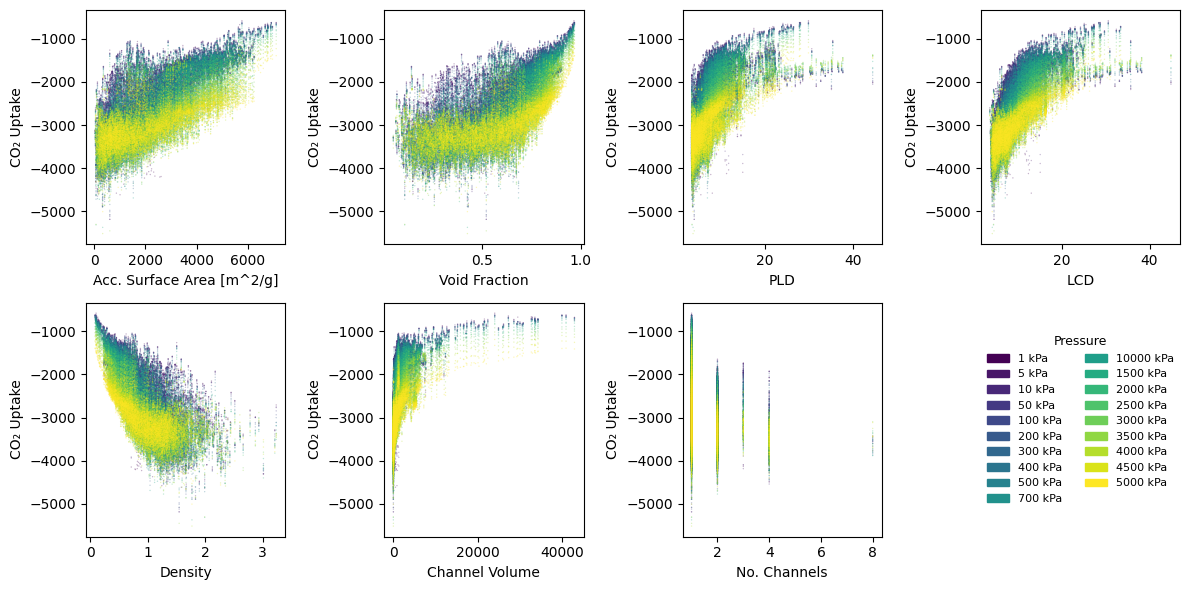

In [5]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

output_name = 'heat'
x_vals = data_H['H'][:,:].numpy()  # (5394, 19)
n_cat = x_vals.shape[1]

txt_vals = data_txt.iloc[:,:].values

fig, axes = plt.subplots(2, 4, figsize=(12,6))
axes = axes.flatten()

cmap = plt.get_cmap('viridis', n_cat)

for idx in range(7):
    ax = axes[idx]
    feature = txt_vals[:, idx+1]

    x_all = np.tile(feature, n_cat)
    y_all = x_vals.flatten('F')
    c_all = np.repeat(np.arange(n_cat), len(feature))

    ax.scatter(x_all, y_all, c=c_all, cmap='viridis', vmin=0, vmax=n_cat-1,
               s=1, alpha=0.3, linewidths=0, rasterized=True)
    ax.set_xlabel(data_txt.columns[idx+1])
    ax.set_ylabel("CO₂ Uptake")

# Use the last (8th) subplot for the legend
legend_ax = axes[-1]
legend_ax.set_visible(True)
legend_ax.axis('off')

legend_handles = [
    mpatches.Patch(color=cmap(i / (n_cat - 1)), label=f'{data_pressure[i]} kPa')
    for i in range(n_cat)
]

legend_ax.legend(
    handles=legend_handles,
    title="Pressure",
    loc='center',
    fontsize=8,
    title_fontsize=9,
    ncol=2 if n_cat > 10 else 1,
    frameon=False
)

plt.tight_layout()
plt.savefig(f"./data/isotherm/{output_name}_scatter.png", dpi=120)
print("Done!")

Done!: p = 4500


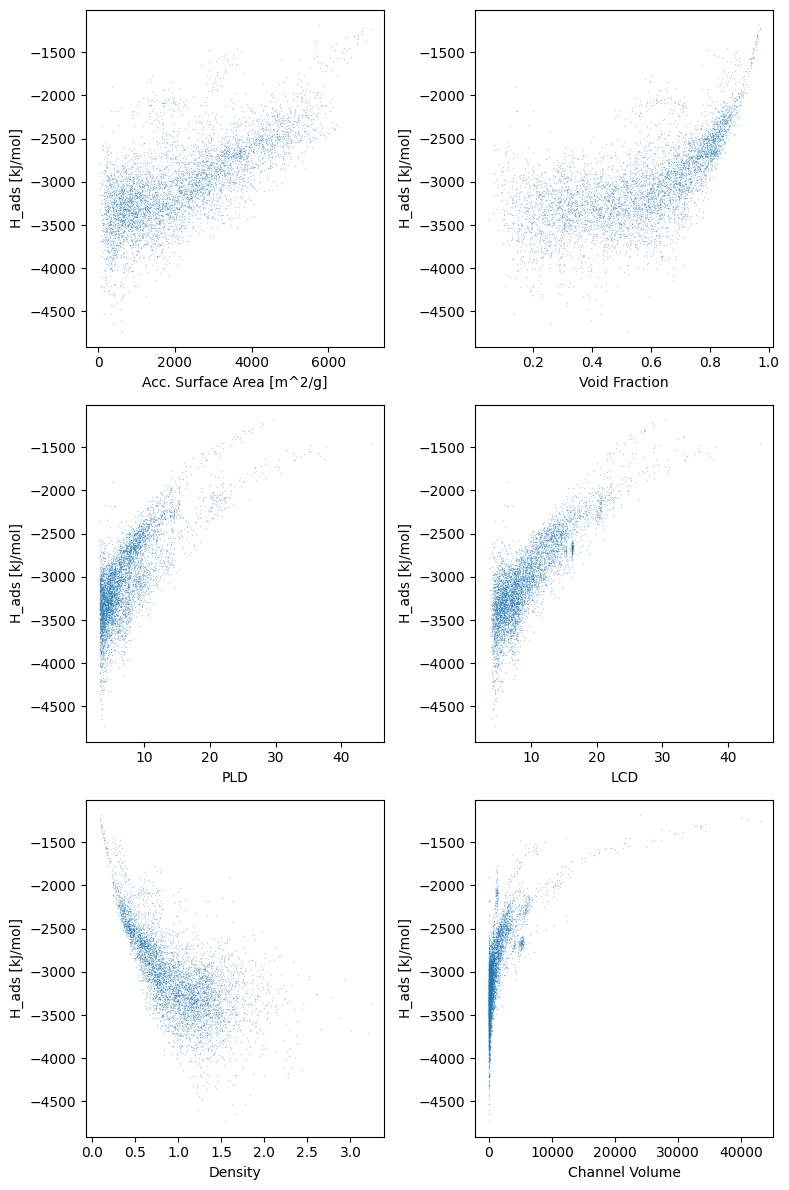

In [6]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np

p_idx = 17
p_val = data_pressure[p_idx]

output_name = 'heat'
output_label = 'H_ads [kJ/mol]'
# output_name = 'isotherm'
# output_label = 'CO₂ Uptake [g/g]'

y_atP = data_H['H'][:,p_idx:p_idx+1].numpy()  # (5394, 19)
# y_atP = data_y['isotherm'][:,p_idx:p_idx+1].numpy()  # (5394, 19)
feat_vals = data_txt.iloc[:,1:-1].values
feat_names = data_txt.columns.tolist()[1:-1]

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
axes = axes.flatten()

for idx in range(feat_vals.shape[1]):
    ax = axes[idx]
    feat_i = feat_vals[:,idx]

    ax.scatter(feat_i, y_atP,
               s=1, alpha=0.3, linewidths=0, rasterized=True)
    ax.set_xlabel(feat_names[idx])
    ax.set_ylabel(output_label)

# axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f"./data/isotherm/{output_name}_scatter_at_{p_val}.png", dpi=120)
print(f"Done!: p = {p_val}")


In [7]:
data_to_save = np.concatenate([feat_vals, y_atP], axis=1)
names_to_save = feat_names+[output_label]

df_to_save = pd.DataFrame(data_to_save, columns=names_to_save)
print(df_to_save.head())
if output_name == 'heat':
    file_tag = 'ITHH'
else:
    file_tag = 'ITG'
df_to_save.to_csv(f"./data/{file_tag}{p_val}.csv")
print(f'Saved as "./data/{file_tag}{p_val}.csv"')

   Acc. Surface Area [m^2/g]  Void Fraction      PLD       LCD   Density   
0                   3247.670       0.759906  8.63647  14.99836  0.596568  \
1                   1216.270       0.455216  6.42473   8.69704  1.243110   
2                   1159.510       0.412831  8.60619   8.80218  1.085760   
3                    460.682       0.267865  5.37127   5.95497  1.590150   
4                   4487.680       0.782606  7.68602   9.42926  0.564412   

   Channel Volume  H_ads [kJ/mol]  
0       2133.2000    -2651.178223  
1        279.9240    -3003.492676  
2        536.4930    -2777.999023  
3         48.7912    -3137.602295  
4       1553.0100    -2837.546387  
Saved as "./data/ITHH4500.csv"
